In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
import sys
print(sys.executable)
warnings.filterwarnings('ignore')

print("All imports successful!")

c:\Users\ASUS\Documents\Tata\.venv\Scripts\python.exe
All imports successful!


In [2]:
# Column names for CMAPSS dataset
columns = ['engine_id', 'cycle', 'setting1', 'setting2', 'setting3'] + \
          [f'sensor{i}' for i in range(1, 22)]

# Load training data
train_df = pd.read_csv(
    '../data/raw/train_FD001.txt',
    sep='\s+',
    header=None,
    names=columns
)

# Load test data
test_df = pd.read_csv(
    '../data/raw/test_FD001.txt',
    sep='\s+',
    header=None,
    names=columns
)

# Load RUL labels
rul_df = pd.read_csv(
    '../data/raw/RUL_FD001.txt',
    header=None,
    names=['RUL']
)

print(f"Train shape: {train_df.shape}")
print(f"Test shape:  {test_df.shape}")
print(f"RUL shape:   {rul_df.shape}")
train_df.head()

Train shape: (20631, 26)
Test shape:  (13096, 26)
RUL shape:   (100, 1)


,engine_id,cycle,setting1,setting2,setting3,sensor1,sensor2,sensor3,sensor4,sensor5,...,sensor12,sensor13,sensor14,sensor15,sensor16,sensor17,sensor18,sensor19,sensor20,sensor21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [3]:
# Calculate RUL for each engine in training set
# RUL = max cycle for that engine - current cycle
max_cycles = train_df.groupby('engine_id')['cycle'].max().reset_index()
max_cycles.columns = ['engine_id', 'max_cycle']

train_df = train_df.merge(max_cycles, on='engine_id')
train_df['RUL'] = train_df['max_cycle'] - train_df['cycle']
train_df.drop(columns=['max_cycle'], inplace=True)

print(f"Max RUL: {train_df['RUL'].max()}")
print(f"Min RUL: {train_df['RUL'].min()}")
print(f"Total engines: {train_df['engine_id'].nunique()}")
train_df[['engine_id', 'cycle', 'RUL']].head(10)

Max RUL: 361
Min RUL: 0
Total engines: 100


,engine_id,cycle,RUL
0,1,1,191
1,1,2,190
2,1,3,189
3,1,4,188
4,1,5,187
5,1,6,186
6,1,7,185
7,1,8,184
8,1,9,183
9,1,10,182


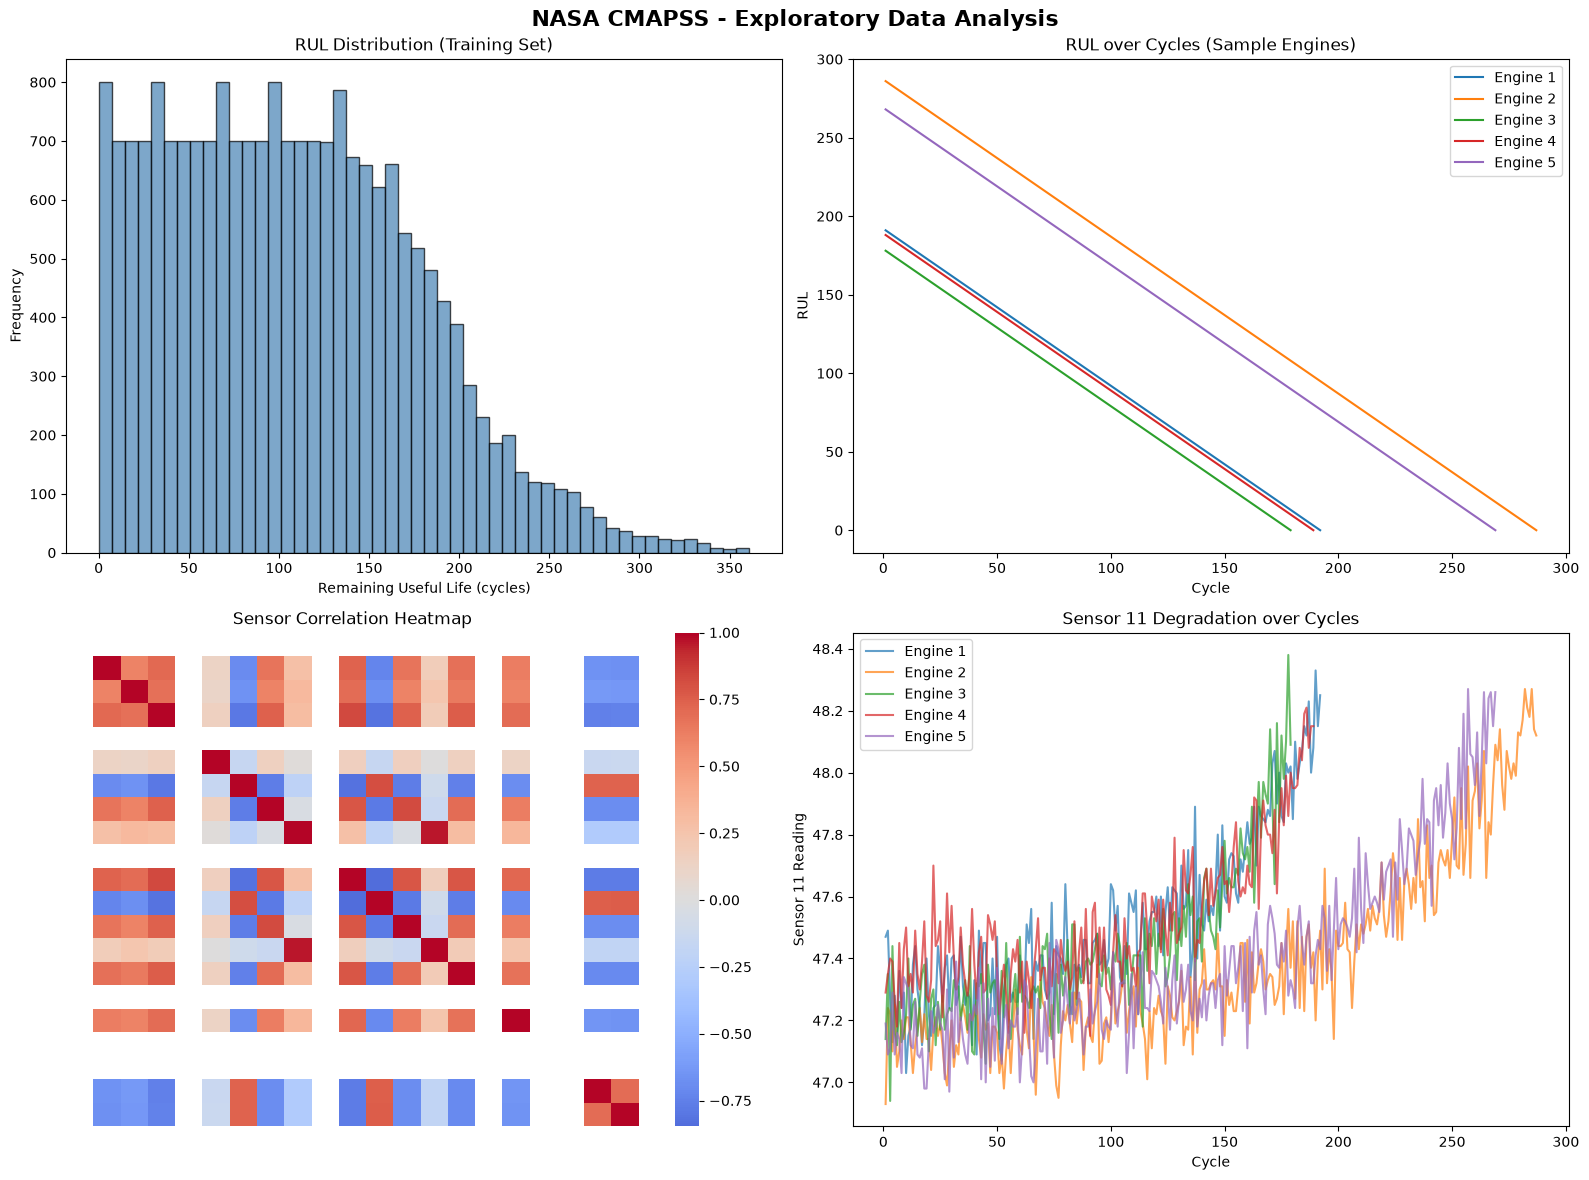

EDA plots saved to docs/


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('NASA CMAPSS - Exploratory Data Analysis', fontsize=16, fontweight='bold')

# Plot 1 — RUL distribution
axes[0,0].hist(train_df['RUL'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0,0].set_title('RUL Distribution (Training Set)')
axes[0,0].set_xlabel('Remaining Useful Life (cycles)')
axes[0,0].set_ylabel('Frequency')

# Plot 2 — Engine lifecycle (first 5 engines)
for eid in range(1, 6):
    eng = train_df[train_df['engine_id'] == eid]
    axes[0,1].plot(eng['cycle'], eng['RUL'], label=f'Engine {eid}')
axes[0,1].set_title('RUL over Cycles (Sample Engines)')
axes[0,1].set_xlabel('Cycle')
axes[0,1].set_ylabel('RUL')
axes[0,1].legend()

# Plot 3 — Sensor correlation heatmap
sensor_cols = [f'sensor{i}' for i in range(1, 22)]
corr = train_df[sensor_cols].corr()
sns.heatmap(corr, ax=axes[1,0], cmap='coolwarm', center=0,
            xticklabels=False, yticklabels=False)
axes[1,0].set_title('Sensor Correlation Heatmap')

# Plot 4 — Sensor degradation over time (sensor 11 - most informative)
for eid in range(1, 6):
    eng = train_df[train_df['engine_id'] == eid]
    axes[1,1].plot(eng['cycle'], eng['sensor11'], alpha=0.7, label=f'Engine {eid}')
axes[1,1].set_title('Sensor 11 Degradation over Cycles')
axes[1,1].set_xlabel('Cycle')
axes[1,1].set_ylabel('Sensor 11 Reading')
axes[1,1].legend()

plt.tight_layout()
plt.savefig('../docs/eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("EDA plots saved to docs/")